In [1]:
import pandas as pd
import seaborn as sns

# import warnings; warnings.simplefilter('ignore')

%matplotlib inline

The line below calls the package manager for Python pip and installs a package. We only want to do this once.

The first time you run this notebook please uncomment this line and then comment it again to avoid unneccessary installs and checks. You could also use anaconda or pip from the command line to permanently install the package.

In [4]:
# !pip install aequitas

Defaulting to user installation because normal site-packages is not writeable


In [5]:
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
import aequitas.plot as ap

In [6]:
df = pd.read_csv("https://github.com/dssg/aequitas/raw/master/examples/data/compas_for_aequitas.csv")

#### Task 1: Check the contents of the data file in terms of both, attributes-values and number of rows

In [8]:
# Your code for task 1

# Display the first few rows of the DataFrame
print("First few rows of the dataset:")
print(df.head())
# Display summary statistics of the dataset
print("\nSummary statistics of the dataset:")
print(df.describe())

First few rows of the dataset:
   entity_id  score  label_value              race   sex          age_cat
0          1    0.0            0             Other  Male  Greater than 45
1          3    0.0            1  African-American  Male          25 - 45
2          4    0.0            1  African-American  Male     Less than 25
3          5    1.0            0  African-American  Male     Less than 25
4          6    0.0            0             Other  Male          25 - 45

Summary statistics of the dataset:
          entity_id        score  label_value
count   7214.000000  7214.000000  7214.000000
mean    5501.255753     0.459800     0.450652
std     3175.706870     0.498416     0.497593
min        1.000000     0.000000     0.000000
25%     2735.250000     0.000000     0.000000
50%     5509.500000     0.000000     0.000000
75%     8246.500000     1.000000     1.000000
max    11001.000000     1.000000     1.000000


In [9]:
# Your code for task 1
# Display information about the dataset, including data types and non-null counts
print("\nInformation about the dataset:")
print(df.info())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity_id    7214 non-null   int64  
 1   score        7214 non-null   float64
 2   label_value  7214 non-null   int64  
 3   race         7214 non-null   object 
 4   sex          7214 non-null   object 
 5   age_cat      7214 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 338.3+ KB
None


In [10]:
aq_palette = sns.diverging_palette(225, 35, n=2)

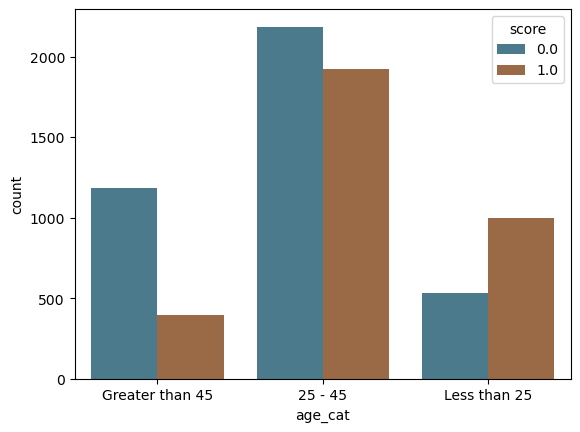

In [11]:
by_age = sns.countplot(x="age_cat", hue="score", data=df, palette=aq_palette)

#### Task 2: Study the histogram as depicted above and try to interpret the histogram. What is the intention of the data scientist in this case? Subsequently, check the distributions for the same attribute, this time, however, in relation to what has really happened and state your observations by also explaining an indication of a potential bias in the model.

**Your answer for task 2 in this cell:**

In [9]:
# Your code for task 2

#### Task 3: Repeat the previous explorations. this time, however, for the other two attributes: race and gender. Susequently, interpret  the results and explain any indication of a potential bias in the model.

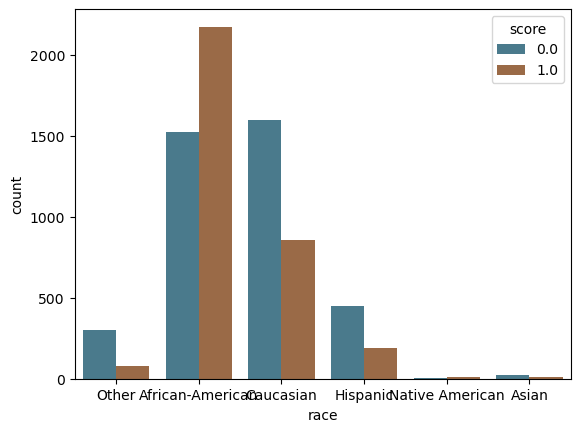

In [13]:
# Your code for task3
# Define a custom color palette
aq_palette_race = sns.diverging_palette(225, 35, n=2)

# Create a count plot to visualize the distribution of scores across race categories
by_race = sns.countplot(x="race", hue="score", data=df, palette=aq_palette_race)


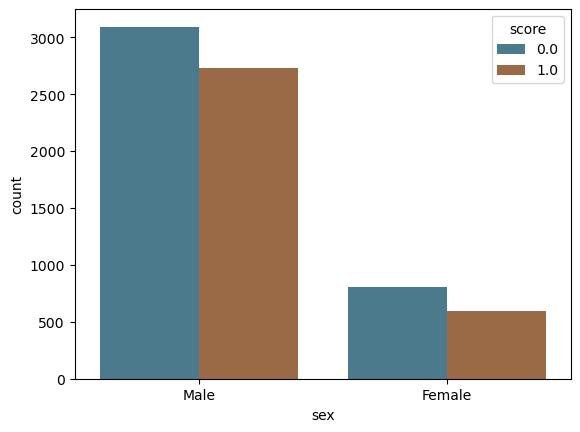

In [16]:
# Your code for task 3
# Define a custom color palette
aq_palette_gender = sns.diverging_palette(225, 35, n=2)

# Create a count plot to visualize the distribution of scores across gender categories
by_gender = sns.countplot(x="sex", hue="score", data=df, palette=aq_palette_gender)


**Your answer for task 3 in this cell: **

In [17]:
g = Group()
xtab, _ = g.get_crosstabs(df)

In [18]:
absolute_metrics = g.list_absolute_metrics(xtab)

In [19]:
xtab[[col for col in xtab.columns if col not in absolute_metrics]]

,model_id,score_threshold,k,attribute_name,attribute_value,pp,pn,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities
0,0,binary 0/1,3317,race,African-American,2174,1522,805,532,990,1369,1901,1795,3696,7214
1,0,binary 0/1,3317,race,Asian,8,24,2,3,21,6,9,23,32,7214
2,0,binary 0/1,3317,race,Caucasian,854,1600,349,461,1139,505,966,1488,2454,7214
3,0,binary 0/1,3317,race,Hispanic,190,447,87,129,318,103,232,405,637,7214
4,0,binary 0/1,3317,race,Native American,12,6,3,1,5,9,10,8,18,7214
5,0,binary 0/1,3317,race,Other,79,298,36,90,208,43,133,244,377,7214
6,0,binary 0/1,3317,sex,Female,591,804,288,195,609,303,498,897,1395,7214
7,0,binary 0/1,3317,sex,Male,2726,3093,994,1021,2072,1732,2753,3066,5819,7214
8,0,binary 0/1,3317,age_cat,25 - 45,1924,2185,741,706,1479,1183,1889,2220,4109,7214
9,0,binary 0/1,3317,age_cat,Greater than 45,394,1182,181,285,897,213,498,1078,1576,7214


In [20]:
xtab[['attribute_name', 'attribute_value'] + absolute_metrics].round(2)

,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,race,African-American,0.72,0.55,0.35,0.37,0.45,0.28,0.65,0.63,0.66,0.59,0.51
1,race,Asian,0.67,0.91,0.12,0.25,0.09,0.33,0.88,0.75,0.00,0.25,0.28
2,race,Caucasian,0.52,0.77,0.29,0.41,0.23,0.48,0.71,0.59,0.26,0.35,0.39
3,race,Hispanic,0.44,0.79,0.29,0.46,0.21,0.56,0.71,0.54,0.06,0.30,0.36
4,race,Native American,0.90,0.62,0.17,0.25,0.38,0.10,0.83,0.75,0.00,0.67,0.56
5,race,Other,0.32,0.85,0.30,0.46,0.15,0.68,0.70,0.54,0.02,0.21,0.35
6,sex,Female,0.61,0.68,0.24,0.49,0.32,0.39,0.76,0.51,0.18,0.42,0.36
7,sex,Male,0.63,0.68,0.33,0.36,0.32,0.37,0.67,0.64,0.82,0.47,0.47
8,age_cat,25 - 45,0.63,0.67,0.32,0.39,0.33,0.37,0.68,0.61,0.58,0.47,0.46
9,age_cat,Greater than 45,0.43,0.83,0.24,0.46,0.17,0.57,0.76,0.54,0.12,0.25,0.32


#### Task 4: Study the two tables above with the metrics and suggest those metrics, which may further indicate bias by constrasting groups for the attribute "race" and "age_cat". As a guidance for the selected metrics, you should consider the model and its application as being a "punitive example" rather than an "assistive" one. Justify your answer regarding indicative bias. You should also give the definition for each selected metric.

**Your answer for task 4 in this cell:**

#### Task 5: In the following, fill in the missing pieces of code to the disparities among all possible groups and for all of the above metrics. Disparities are calculated as a ratio of a metric for a group of interest compared to a base group. In our case, you should set the follwoing groups as base rate: Caucasian / Male /  Age 25-45.

In [22]:
b = Bias()

In [25]:
print(df.columns)

Index(['entity_id', 'score', 'label_value', 'race', 'sex', 'age_cat'], dtype='object')


In [39]:
# Specify the base reference groups
base_reference_groups = {
    'race': 'Caucasian',
    'sex': 'Male',
    'age_cat': '25 - 45'
}

# Initialize an empty DataFrame to store disparities
all_disparities = pd.DataFrame()

# Loop through each attribute and calculate disparities
for attribute in ['race', 'sex', 'age_cat']:
    # Set the group of interest
    group_of_interest = {attribute: df[attribute].unique()}

    # Set the reference groups
    ref_groups_dict = {**base_reference_groups, **group_of_interest}

    try:
        # Compute disparity metrics
        bdf = b.get_disparity_predefined_groups(xtab, original_df=df,
                                                        ref_groups_dict=ref_groups_dict,
                                                        alpha=0.05, check_significance=True,
                                                        mask_significance=True)

        # Add attribute name to the disparities DataFrame
        bdf['attribute_name'] = attribute

        # Concatenate disparities for each attribute
        all_disparities = pd.concat([all_disparities, disparities])
    except Exception as e:
        print(f"Error for attribute {attribute}: {e}")

# Display the styled output of all disparities
all_disparities.style

get_disparity_predefined_group()
Error for attribute race: get_disparity_predefined_groups(): reference groups and values provided do not exist as columns/values in the input dataframe.(Note: check for syntax errors)
get_disparity_predefined_group()
Error for attribute sex: get_disparity_predefined_groups(): reference groups and values provided do not exist as columns/values in the input dataframe.(Note: check for syntax errors)
get_disparity_predefined_group()
Error for attribute age_cat: get_disparity_predefined_groups(): reference groups and values provided do not exist as columns/values in the input dataframe.(Note: check for syntax errors)


In [40]:
# View disparity metrics added to dataframe
bdf[['attribute_name', 'attribute_value'] +
     b.list_disparities(bdf) + b.list_significance(bdf)].style

NameError: name 'bdf' is not defined

In [38]:
metrics = ['fpr','fdr']
disparity_tolerance = 1.25

#### Task 6: Having observed the code in the cell above, which values for which disparities are highly likely to indicate bias in the disparity table above?

**Your answer for task 6 in this cell:**